# Q-Caliber: Quantum-Calibrated Graph Diffusion

**Q-Caliber** (Quantum-Calibrated Graph Diffusion) is a novel approach that uses *local* quantum-walk statistics from sampled subnetworks to calibrate parameters $\theta$ of a *global* graph diffusion operator $g_{\theta}(L)$. This enables scalable graph learning by combining quantum walk insights with classical diffusion methods.

## Key Innovation

Instead of running expensive quantum walks on the full graph, Q-Caliber:
1. Samples representative subnetworks (ego-nets)
2. Runs quantum walks (CTQW) on these small subgraphs using **Hiperwalk**
3. Fits global diffusion parameters (heat kernel or polynomial filter) to match quantum walk behavior
4. Applies the calibrated classical operator $g_{\theta}(L)$ to the full graph

This hybrid approach achieves quantum-informed diffusion at classical computational cost.

## Prerequisites

All required packages are in `requirements.txt`. Install with:
```bash
pip install -r requirements.txt
```

Key dependencies: `hiperwalk`, `numpy`, `scipy`, `networkx`, `matplotlib`, `scikit-learn`

## Notebook Outline

1. **Load graph**: Biological network (PPI/gene-gene) or synthetic graph
2. **Sample subnetworks**: Coverage-aware ego-net sampling using QuVINE
3. **Quantum walk simulation**: Run CTQW on subnetworks with QuVINE's Hiperwalk integration
4. **Parameter calibration**: Fit global filter parameters $\theta$ (heat kernel or polynomial)
5. **Apply & evaluate**: Use calibrated $g_{\theta}(L)$ for node classification/ranking

# Imports

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import networkx as nx
import matplotlib.pyplot as plt

# QuVINE imports
from quvine.data.subgraph import (
    expand_neighborhood,
    induce_subgraph_by_nodes,
    subsample_nodes_with_protected
)
from quvine.walks.ctqw import generate_ctqw_hiperwalk_scores
from quvine.utils.utilities import get_stats

# Try importing Hiperwalk
try:
    import hiperwalk as hpw
    HIPERWALK_AVAILABLE = True
except Exception as e:
    HIPERWALK_AVAILABLE = False
    print('Hiperwalk import failed. Install with: pip install hiperwalk')
    print('Error:', e)

# Optional sklearn
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

## 1) Load (or generate) a graph

In practice, replace the toy graph below with your PPI adjacency (e.g., BioGRID/STRING) using QuVINE's `load_graph()` function.

For a quick prototype, we generate a graph and treat a small set of nodes as "seed" disease genes.

In [2]:
# Toy graph generator (replace with real PPI using quvine.data.data_loader.load_graph)
np.random.seed(7)
N0 = 300
p = 0.02
G = nx.erdos_renyi_graph(N0, p, seed=7)
G = nx.convert_node_labels_to_integers(G)

# Ensure connectivity for convenience
if not nx.is_connected(G):
    largest = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest).copy()
    # IMPORTANT: Relabel nodes to be contiguous integers starting from 0
    G = nx.convert_node_labels_to_integers(G, first_label=0)

N = G.number_of_nodes()
print('Nodes:', N, 'Edges:', G.number_of_edges())

# Create node-to-index mapping (nodes should already be 0 to N-1)
nodes_list = list(G.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}
print(f'Node IDs range: {min(nodes_list)} to {max(nodes_list)}')

# Display graph statistics using QuVINE utility
stats = get_stats(G)
print('\nGraph Statistics:')
for key, value in stats.items():
    print(f'  {key}: {value}')

# Example seed genes (replace with disease seeds)
seed_nodes = np.random.choice(nodes_list, size=5, replace=False).tolist()
print('\nSeed nodes:', seed_nodes)

# Adjacency and Laplacian
A = nx.to_scipy_sparse_array(G, format='csr', dtype=float)
# combinatorial Laplacian L = D - A
deg = np.array(A.sum(axis=1)).reshape(-1)
L = sp.diags(deg) - A

Nodes: 297 Edges: 887
Node IDs range: 0 to 296

Graph Statistics:
  num_nodes: 297
  num_edges: 887
  density: 0.020179270179270178
  average_degree: 5.973
  average_clustering_coefficient: 0.016
  average_betweenness: 0.008
  average_assortavity_coefficient: -0.02
  num_connected_components: 1
  largest_cc_size: 297

Seed nodes: [199, 3, 216, 284, 125]


## 2) Coverage-aware subnetwork sampling using QuVINE

We use QuVINE's `expand_neighborhood` and `induce_subgraph_by_nodes` functions to sample ego-nets around seeds and additional nodes via importance sampling.

In [3]:
def get_ego_net_nodes_quvine(G, center, k=2, max_nodes=None):
    """
    Get ego-net nodes using QuVINE's expand_neighborhood function.
    
    Args:
        G: NetworkX graph
        center: Center node
        k: Hop radius
        max_nodes: Maximum number of nodes (optional truncation)
    
    Returns:
        List of nodes in the ego-net
    """
    # Use QuVINE's expand_neighborhood function
    nodes = expand_neighborhood(G, roots={center}, radius=k)
    nodes = list(nodes)
    
    if max_nodes is not None and len(nodes) > max_nodes:
        # Keep center + top-degree neighbors first
        nodes_sorted = sorted(nodes, key=lambda n: G.degree[n], reverse=True)
        if center in nodes_sorted:
            nodes_sorted.remove(center)
        nodes = [center] + nodes_sorted[:max_nodes-1]
    
    return nodes


def importance_sample_centers(G, m, exclude=set(), bins=6, seed=0):
    """
    Sample m centers without replacement, stratified by degree bins.
    
    Args:
        G: NetworkX graph
        m: Number of centers to sample
        exclude: Set of nodes to exclude
        bins: Number of degree bins for stratification
        seed: Random seed
    
    Returns:
        List of sampled center nodes
    """
    rng = np.random.default_rng(seed)
    nodes = np.array([n for n in G.nodes() if n not in exclude])
    degrees = np.array([G.degree[n] for n in nodes])

    qs = np.quantile(degrees, np.linspace(0, 1, bins+1))
    strata = []
    for i in range(bins):
        lo, hi = qs[i], qs[i+1]
        mask = (degrees >= lo) & (degrees <= hi) if i == bins-1 else (degrees >= lo) & (degrees < hi)
        strata.append(nodes[mask])

    per = int(np.ceil(m / bins))
    chosen = []
    for s in strata:
        if len(chosen) >= m:
            break
        if len(s) == 0:
            continue
        k = min(per, m - len(chosen), len(s))
        chosen.extend(rng.choice(s, size=k, replace=False).tolist())

    if len(chosen) < m:
        remaining = np.array([n for n in nodes if n not in set(chosen)])
        k = m - len(chosen)
        if len(remaining) > 0:
            chosen.extend(rng.choice(remaining, size=min(k, len(remaining)), replace=False).tolist())

    return chosen[:m]


# Build subnetwork set
subnets = []
for s in seed_nodes:
    subnets.append(get_ego_net_nodes_quvine(G, s, k=2, max_nodes=60))

extra_centers = importance_sample_centers(G, m=15, exclude=set(seed_nodes), bins=6, seed=7)
for c in extra_centers:
    subnets.append(get_ego_net_nodes_quvine(G, c, k=2, max_nodes=60))

print('#subnetworks:', len(subnets), 'avg size:', float(np.mean([len(S) for S in subnets])))

#subnetworks: 20 avg size: 36.65


## 3) Quantum-walk simulation using QuVINE's CTQW module

We use QuVINE's `generate_ctqw_hiperwalk_scores` function to run continuous-time quantum walks on each induced subgraph.

In [4]:
def get_subgraph_and_mapping(G, nodes):
    """
    Get induced subgraph using QuVINE's induce_subgraph_by_nodes.
    
    Args:
        G: NetworkX graph
        nodes: List of nodes
    
    Returns:
        Tuple of (subgraph, node_to_index_mapping, nodes_list)
    """
    nodes = list(nodes)
    idx = {n: i for i, n in enumerate(nodes)}
    H = induce_subgraph_by_nodes(G, set(nodes))
    return H, idx, nodes


def classical_heat_prob(A_sub, start_local, t=1.0):
    """
    Fallback: classical heat diffusion on subgraph Laplacian.
    Used when Hiperwalk is not available.
    """
    from scipy.linalg import expm
    n = A_sub.shape[0]
    deg = A_sub.sum(axis=1)
    Ls = np.diag(deg) - A_sub
    e0 = np.zeros(n)
    e0[start_local] = 1.0
    v = expm(-t*Ls) @ e0
    v = np.maximum(v, 0)
    return v / v.sum() if v.sum() > 0 else v


# Compute local quantum targets p_Q^S using QuVINE's CTQW function
q_targets = []
for S in subnets:
    center = S[0]
    H_sub, idx, nodes_list = get_subgraph_and_mapping(G, S)
    
    if HIPERWALK_AVAILABLE:
        # Use QuVINE's generate_ctqw_hiperwalk_scores function
        try:
            scores = generate_ctqw_hiperwalk_scores(
                G=G,
                root=center,
                view_nodes=nodes_list,
                steps=25,
                gamma=1.0
            )
            # Convert scores dict to probability array in node order
            pQ = np.array([scores.get(n, 0.0) for n in nodes_list])
            pQ = pQ / pQ.sum() if pQ.sum() > 0 else pQ
        except Exception as e:
            print(f"Warning: CTQW failed for center {center}, using classical fallback. Error: {e}")
            A_sub = nx.to_numpy_array(H_sub, nodelist=nodes_list, dtype=float)
            start_local = idx[center]
            pQ = classical_heat_prob(A_sub, start_local, t=1.0)
    else:
        # Fallback to classical heat diffusion
        A_sub = nx.to_numpy_array(H_sub, nodelist=nodes_list, dtype=float)
        start_local = idx[center]
        pQ = classical_heat_prob(A_sub, start_local, t=1.0)

    q_targets.append({'nodes': nodes_list, 'center': center, 'pQ': pQ})

print('Computed targets for', len(q_targets), 'subnetworks')
print('Example target length:', len(q_targets[0]['pQ']))

Computed targets for 20 subnetworks
Example target length: 34


## 4) Fit global filter parameters $\theta$

We define a *global* operator $g_{\theta}(L)$ on the **full graph** and compare its output restricted to subnetwork nodes.

### 4A) Heat-kernel parameter $t$
$g_t(L)=\exp(-tL)$, fit by grid search.

In [5]:
def expm_multiply_restricted(L, t, x, node_indices, node_to_idx):
    """
    Compute y = exp(-tL) x and return y restricted to specified nodes.
    
    Args:
        L: Laplacian matrix (sparse)
        t: Time parameter
        x: Initial vector
        node_indices: List of node IDs to restrict output
        node_to_idx: Dictionary mapping node IDs to matrix indices
    
    Returns:
        Restricted output vector
    """
    y = spla.expm_multiply((-t) * L, x)
    # Convert node IDs to matrix indices
    idx_list = [node_to_idx[n] for n in node_indices]
    return np.asarray(y)[idx_list]


def fit_heat_time(L, q_targets, t_grid, node_to_idx, loss='l2'):
    """
    Fit heat kernel time parameter by matching quantum walk targets.
    
    Args:
        L: Laplacian matrix
        q_targets: List of quantum walk target distributions
        t_grid: Grid of time values to search
        node_to_idx: Dictionary mapping node IDs to matrix indices
        loss: Loss function ('l2' or 'kl')
    
    Returns:
        Tuple of (best_loss, best_t)
    """
    best_loss, best_t = np.inf, None
    N = L.shape[0]

    for t in t_grid:
        tot = 0.0
        for item in q_targets:
            nodes = item['nodes']
            center = item['center']
            pQ = item['pQ']

            x = np.zeros(N)
            x[node_to_idx[center]] = 1.0

            yS = expm_multiply_restricted(L, t, x, nodes, node_to_idx)
            yS = np.maximum(yS, 0)
            pT = yS / yS.sum() if yS.sum() > 0 else yS

            if loss == 'l2':
                tot += np.sum((pT - pQ) ** 2)
            elif loss == 'kl':
                eps = 1e-12
                tot += np.sum(pQ * (np.log(pQ + eps) - np.log(pT + eps)))
            else:
                raise ValueError('Unknown loss')

        if tot < best_loss:
            best_loss, best_t = tot, t

    return best_loss, best_t


t_grid = np.linspace(0.1, 5.0, 20)
loss_val, t_star = fit_heat_time(L, q_targets, t_grid, node_to_idx, loss='l2')
print('Best t:', t_star, 'loss:', loss_val)

Best t: 0.6157894736842106 loss: 2.4435021154165324


### 4B) Polynomial filter coefficients $\{a_k\}$

Approximate $g(L)$ by $g_{\theta}(L)=\sum_{k=0}^K a_k L^k$ and fit $a_k$ by least squares on the restricted subnetwork targets.

In [6]:
def apply_poly_filter(L, coeffs, x):
    """
    Compute y = sum_k a_k L^k x using sparse matvecs.
    
    Args:
        L: Laplacian matrix
        coeffs: Polynomial coefficients
        x: Input vector
    
    Returns:
        Filtered output vector
    """
    y = coeffs[0] * x
    v = x.copy()
    for k in range(1, len(coeffs)):
        v = L @ v
        y = y + coeffs[k] * v
    return np.asarray(y)


def fit_poly_coeffs(L, q_targets, node_to_idx, K=4, ridge=1e-6):
    """
    Fit polynomial filter coefficients by least squares.
    
    Args:
        L: Laplacian matrix
        q_targets: List of quantum walk target distributions
        node_to_idx: Dictionary mapping node IDs to matrix indices
        K: Polynomial degree
        ridge: Ridge regularization parameter
    
    Returns:
        Array of polynomial coefficients
    """
    AtA = np.zeros((K + 1, K + 1))
    Atb = np.zeros(K + 1)
    N = L.shape[0]

    for item in q_targets:
        nodes = item['nodes']
        center = item['center']
        pQ = item['pQ']

        x = np.zeros(N)
        x[node_to_idx[center]] = 1.0

        basis = []
        v = x.copy()
        # Convert node IDs to indices for extraction
        node_indices = [node_to_idx[n] for n in nodes]
        basis.append(v[node_indices])
        for _ in range(1, K + 1):
            v = L @ v
            basis.append(np.asarray(v)[node_indices])

        Phi = np.stack(basis, axis=1)  # |S| x (K+1)
        b = pQ

        AtA += Phi.T @ Phi
        Atb += Phi.T @ b

    AtA += ridge * np.eye(K + 1)
    return np.linalg.solve(AtA, Atb)


poly_coeffs = fit_poly_coeffs(L, q_targets, node_to_idx, K=4, ridge=1e-6)
print('Polynomial coeffs:', poly_coeffs)

Polynomial coeffs: [ 1.71750726e+00 -6.68746166e-01  1.09498428e-01 -7.93622747e-03
  2.11116477e-04]


## 5) Apply calibrated operator to node features and train a simple model

We compute $Z = g_{\theta}(L)X$ and train a lightweight classifier.

Replace the toy features/labels with real omics features and disease-gene labels.

In [7]:
# Toy node features (replace with real features)
F = 16
X = np.random.normal(size=(N, F))

# Toy labels: mark seeds as positives (replace with known disease genes)
y = np.zeros(N, dtype=int)
for seed in seed_nodes:
    y[node_to_idx[seed]] = 1

# Apply heat filter with t_star
Z_heat = np.zeros_like(X)
for f in range(F):
    Z_heat[:, f] = spla.expm_multiply((-t_star) * L, X[:, f])

# Apply polynomial filter
Z_poly = np.zeros_like(X)
for f in range(F):
    Z_poly[:, f] = apply_poly_filter(L, poly_coeffs, X[:, f])

print('Z_heat shape:', Z_heat.shape, 'Z_poly shape:', Z_poly.shape)

Z_heat shape: (297, 16) Z_poly shape: (297, 16)


### Train/evaluate (quick sanity check)

This uses logistic regression if `scikit-learn` is available.

In [ ]:
if not SKLEARN_AVAILABLE:
    print('scikit-learn not available; skipping classifier demo')
else:
    rng = np.random.default_rng(0)
    idx = np.arange(N)
    rng.shuffle(idx)
    split = int(0.8 * N)
    tr, te = idx[:split], idx[split:]

    def eval_model(Z, name):
        clf = LogisticRegression(max_iter=2000)
        clf.fit(Z[tr], y=y[tr])
        p = clf.predict_proba(Z[te])[:, 1]
        auc = roc_auc_score(y[te], p)
        ap = average_precision_score(y[te], p)
        print(f'{name}: AUROC={auc:.3f}, AUPRC={ap:.3f}')

    eval_model(X, 'Raw features')
    eval_model(Z_heat, f'Heat-filtered (t={t_star:.2f})')
    eval_model(Z_poly, 'Poly-filtered')

Raw features: AUROC=0.543, AUPRC=0.052
Heat-filtered (t=0.62): AUROC=0.543, AUPRC=0.052
Poly-filtered: AUROC=0.612, AUPRC=0.081


## 6) Integrate Calibrated Diffusion into GNN Architecture

Now we integrate the calibrated quantum-walk parameters into Graph Neural Network (GNN) architectures.

We will:
1. Define GNN architectures that use quantum-calibrated diffusion
2. Optionally tune hyperparameters
3. Train and compare 6 different models
4. Visualize results


### 6A) Q-Caliber Graph Filter Architecture

We define two types of architectures:

**1. Simple Models (Quantum-calibrated Graph Filter + MLP):**
- **QCaliberGraphFilter**: Applies quantum-calibrated diffusion once, then MLP
  - NOT a true GNN (no iterative message passing)
  - More accurately: "Graph filter + MLP"
  - One-shot diffusion: Z = g_θ(L)X, then feed-forward layers
- **BaselineGraphFilter**: Same architecture without quantum calibration

**2. True GNN Models (from gcn_mf.py):**
- **GCNMF**: Graph Convolutional Network + Matrix Factorization
  - Real GNN with iterative message passing
  - Multiple GCN layers with neighborhood aggregation
- **QCaliberGCNMF**: Quantum-calibrated version of GCN-MF
  - Applies calibrated diffusion as preprocessing
  - Then runs true GNN message passing

**Key Distinction:**
- Simple models: One-shot graph filtering (faster, simpler)
- GCN-MF models: Iterative message passing (true GNNs, more expressive)


In [ ]:
# Try importing PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False
    print('PyTorch not available. Install with: pip install torch')


if TORCH_AVAILABLE:
    class QCaliberGraphFilter(nn.Module):
        """
        Q-Caliber Graph Filter + MLP (NOT a true GNN).
        
        This is more accurately a "quantum-calibrated graph filter" followed by MLP,
        not a true GNN with iterative message passing.
        
        Architecture:
        1. Input features X
        2. Apply calibrated diffusion ONCE: Z = g_theta(L) X  (one-shot, not iterative)
        3. MLP layers on diffused features
        4. Output predictions
        
        For true GNN with message passing, see QCaliberGCNMF in gcn_mf.py
        """
        def __init__(self, input_dim, hidden_dim, output_dim, diffusion_type='heat', 
                     t_star=None, poly_coeffs=None, dropout=0.5):
            super(QCaliberGraphFilter, self).__init__()
            self.diffusion_type = diffusion_type
            self.t_star = t_star
            self.poly_coeffs = poly_coeffs
            self.dropout = dropout
            
            # MLP layers after diffusion
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.fc2 = nn.Linear(hidden_dim, hidden_dim)
            self.fc3 = nn.Linear(hidden_dim, output_dim)
            
        def apply_diffusion(self, L, X):
            """Apply calibrated diffusion operator to features."""
            X_np = X.detach().cpu().numpy()
            Z_np = np.zeros_like(X_np)
            
            if self.diffusion_type == 'heat' and self.t_star is not None:
                # Heat kernel diffusion
                for f in range(X_np.shape[1]):
                    Z_np[:, f] = spla.expm_multiply((-self.t_star) * L, X_np[:, f])
            elif self.diffusion_type == 'poly' and self.poly_coeffs is not None:
                # Polynomial filter diffusion
                for f in range(X_np.shape[1]):
                    Z_np[:, f] = apply_poly_filter(L, self.poly_coeffs, X_np[:, f])
            else:
                # No diffusion (identity)
                Z_np = X_np
            
            return torch.from_numpy(Z_np).float().to(X.device)
        
        def forward(self, X, L=None):
            """
            Forward pass.
            
            Args:
                X: Node features [N, input_dim]
                L: Laplacian matrix (for diffusion)
            
            Returns:
                Output predictions [N, output_dim]
            """
            # Apply quantum-calibrated diffusion
            if L is not None:
                Z = self.apply_diffusion(L, X)
            else:
                Z = X
            
            # MLP layers
            h = F.relu(self.fc1(Z))
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = F.relu(self.fc2(h))
            h = F.dropout(h, p=self.dropout, training=self.training)
            out = self.fc3(h)
            
            return out
    
    
    class BaselineGraphFilter(nn.Module):
        """
        Baseline Graph Filter without quantum calibration (standard GCN-style).
        """
        def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
            super(BaselineGraphFilter, self).__init__()
            self.dropout = dropout
            
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.fc2 = nn.Linear(hidden_dim, hidden_dim)
            self.fc3 = nn.Linear(hidden_dim, output_dim)
            
        def forward(self, X, A=None):
            """
            Forward pass with simple adjacency-based aggregation.
            
            Args:
                X: Node features [N, input_dim]
                A: Adjacency matrix (normalized)
            
            Returns:
                Output predictions [N, output_dim]
            """
            # Simple neighborhood aggregation
            if A is not None:
                X_np = X.detach().cpu().numpy()
                Z_np = A @ X_np  # Simple aggregation
                Z = torch.from_numpy(Z_np).float().to(X.device)
            else:
                Z = X
            
            # MLP layers
            h = F.relu(self.fc1(Z))
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = F.relu(self.fc2(h))
            h = F.dropout(h, p=self.dropout, training=self.training)
            out = self.fc3(h)
            
            return out
    
    print('Q-Caliber Graph Filter and Baseline Graph Filter classes defined')
else:
    print('PyTorch not available; skipping GNN implementation')

### 6B) OPTIONAL: Hyperparameter Tuning

**IMPORTANT: This step is OPTIONAL!**

- **Skip this if**: You want to use default parameters (recommended for first run)
- **Run this if**: You want to optimize performance for your specific graph

**What happens here:**
1. Optuna tunes hyperparameters for **ONE model only: QCaliberGCNMF (Heat Kernel)**
2. Tries 30 different hyperparameter combinations for this single model
3. Finds the best parameters based on validation accuracy
4. Saves them in `best_params` variable
5. These same parameters are then **reused for all 6 models** in training (step 6C)

**⚠️ Important Note:**
- Only QCaliberGCNMF (Heat) is actually tuned by Optuna
- The other 5 models use the same optimized parameters (not individually tuned)
- This is a "tune once, apply to all" approach for efficiency

**Time required:** ~10-15 minutes (30 trials for 1 model)

**Parameters being tuned:**
- `hidden_dim`: Hidden layer dimension (16-128)
- `n_layers`: Number of GCN layers (2-4, for GCN-MF models)
- `mf_dim`: Matrix factorization dimension (8-64, for GCN-MF models)
- `dropout`: Dropout rate (0.2-0.7)
- `lr`: Learning rate (1e-4 to 1e-1)
- `weight_decay`: L2 regularization (1e-6 to 1e-3)

**Current Default Parameters:**
- `hidden_dim=32`, `n_layers=2`, `mf_dim=16`
- `dropout=0.5`, `lr=0.01`, `weight_decay=5e-4`

**To use defaults:** Skip to step 6C below

**To optimize:** Run the cell below and wait ~15 minutes

In [41]:
# Initialize with default parameters (will be overwritten if tuning runs)
best_params = {
    'hidden_dim': 32,
    'n_layers': 2,
    'mf_dim': 16,
    'dropout': 0.5,
    'lr': 0.01,
    'weight_decay': 5e-4
}

# Set this to True to run hyperparameter tuning (takes ~10-15 minutes)
# Set to False to use default parameters
RUN_HYPERPARAMETER_TUNING = True  # Change to True to enable tuning

if RUN_HYPERPARAMETER_TUNING:
    # Bayesian Hyperparameter Optimization using Optuna
    # This is the most efficient approach for hyperparameter tuning
    
    try:
        import optuna
        from optuna.visualization import plot_optimization_history, plot_param_importances
        OPTUNA_AVAILABLE = True
    except ImportError:
        OPTUNA_AVAILABLE = False
        print('Optuna not available. Install with: pip install optuna')
    if TORCH_AVAILABLE and SKLEARN_AVAILABLE and OPTUNA_AVAILABLE:
        print('Starting Bayesian hyperparameter optimization with Optuna...')
        print('This will run 30 trials to find optimal hyperparameters\n')
        
        # Define the objective function for Optuna
        def objective(trial):
            """
            Objective function for Optuna optimization.
            Returns validation accuracy to maximize.
            """
            # Suggest hyperparameters
            hidden_dim = trial.suggest_int('hidden_dim', 16, 128, step=16)
            n_layers = trial.suggest_int('n_layers', 2, 4)
            mf_dim = trial.suggest_int('mf_dim', 8, 64, step=8)
            dropout = trial.suggest_float('dropout', 0.2, 0.7)
            lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
            weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
            
            try:
                from quvine.baselines.gcn_mf import QCaliberGCNMF, normalize_adjacency, train_gcn_mf
                
                # Initialize model with suggested hyperparameters
                model = QCaliberGCNMF(
                    n_nodes=N,
                    input_dim=X.shape[1],
                    hidden_dim=hidden_dim,
                    output_dim=2,
                    mf_dim=mf_dim,
                    n_layers=n_layers,
                    dropout=dropout,
                    diffusion_type='heat',  # Use heat kernel for tuning
                    t_star=t_star,
                    L=L
                )
                
                # Prepare data
                A_gcn = normalize_adjacency(A)
                A_gcn_dense = torch.from_numpy(A_gcn.toarray()).float()
                
                # Train with early stopping
                history = train_gcn_mf(
                    model, X_tensor, y_tensor, A_gcn_dense,
                    train_mask, test_mask,
                    epochs=100,  # Fewer epochs for tuning
                    lr=lr,
                    weight_decay=weight_decay,
                    patience=15
                )
                
                # Return best validation accuracy
                return history['best_val_acc']
            
            except Exception as e:
                print(f'Trial failed: {e}')
                # Return a poor score if trial fails
                return 0.0
        
        # Create Optuna study
        study = optuna.create_study(
            direction='maximize',
            study_name='qcaliber_gcnmf_tuning',
            sampler=optuna.samplers.TPESampler(seed=42)  # Tree-structured Parzen Estimator
        )
        
        # Run optimization
        study.optimize(objective, n_trials=30, show_progress_bar=True)
        
        # Print results
        print('\n' + '='*60)
        print('HYPERPARAMETER OPTIMIZATION RESULTS')
        print('='*60)
        print(f'\nBest trial: {study.best_trial.number}')
        print(f'Best validation accuracy: {study.best_value:.4f}')
        print('\nBest hyperparameters:')
        for key, value in study.best_params.items():
            print(f'  {key}: {value}')
        
        # Show parameter importances
        print('\nParameter importances:')
        try:
            importances = optuna.importance.get_param_importances(study)
            for param, importance in importances.items():
                print(f'  {param}: {importance:.4f}')
        except Exception:
            print('  (Could not compute importances)')
        
        # Plot optimization history
        try:
            fig = plot_optimization_history(study)
            fig.show()
            print('\nOptimization history plot displayed')
        except Exception as e:
            print(f'Could not plot optimization history: {e}')
        
        # Plot parameter importances
        try:
            fig = plot_param_importances(study)
            fig.show()
            print('Parameter importance plot displayed')
        except Exception as e:
            print(f'Could not plot parameter importances: {e}')
        
        # Save best parameters for later use
        best_params = study.best_params
        print('\n' + '='*60)
        print('Use these parameters for final model training!')
        print('='*60)
        
    elif not OPTUNA_AVAILABLE:
        print('Optuna not available. Install with: pip install optuna')
        print('Falling back to default hyperparameters')
        best_params = {
            'hidden_dim': 32,
            'n_layers': 2,
            'mf_dim': 16,
            'dropout': 0.5,
            'lr': 0.01,
            'weight_decay': 5e-4
        }
    else:
        print('PyTorch or scikit-learn not available')
        best_params = None
else:
    print('Skipping hyperparameter tuning - using default parameters')
    print('To enable tuning, set RUN_HYPERPARAMETER_TUNING = True above')
    print('\nUsing default parameters:')
    for key, value in best_params.items():
        print(f'  {key}: {value}')


[I 2026-04-02 17:28:35,710] A new study created in memory with name: qcaliber_gcnmf_tuning


Starting Bayesian hyperparameter optimization with Optuna...
This will run 30 trials to find optimal hyperparameters



  0%|          | 0/30 [00:00<?, ?it/s]

Early stopping at epoch 39
[I 2026-04-02 17:28:36,936] Trial 0 finished with value: 0.9833333492279053 and parameters: {'hidden_dim': 48, 'n_layers': 4, 'mf_dim': 48, 'dropout': 0.49932924209851826, 'lr': 0.00029380279387035364, 'weight_decay': 2.9375384576328313e-06}. Best is trial 0 with value: 0.9833333492279053.
Early stopping at epoch 15
[I 2026-04-02 17:28:37,374] Trial 1 finished with value: 0.9833333492279053 and parameters: {'hidden_dim': 16, 'n_layers': 4, 'mf_dim': 40, 'dropout': 0.5540362888980227, 'lr': 0.00011527987128232407, 'weight_decay': 0.0008123245085588687}. Best is trial 0 with value: 0.9833333492279053.
Early stopping at epoch 17
[I 2026-04-02 17:28:37,936] Trial 2 finished with value: 0.9833333492279053 and parameters: {'hidden_dim': 112, 'n_layers': 2, 'mf_dim': 16, 'dropout': 0.2917022549267169, 'lr': 0.0008179499475211679, 'weight_decay': 3.752055855124284e-05}. Best is trial 0 with value: 0.9833333492279053.
Early stopping at epoch 22
[I 2026-04-02 17:28:38,

### 6C) Train Q-Caliber Graph Filter

Train the GNN using the calibrated diffusion operators.

In [42]:
if TORCH_AVAILABLE and SKLEARN_AVAILABLE:
    # Initialize all history variables at the start
    history_gcnmf = None
    history_qcaliber_gcnmf_heat = None
    history_qcaliber_gcnmf_poly = None
    
    # Prepare data
    X_tensor = torch.from_numpy(X).float()
    y_tensor = torch.from_numpy(y).long()
    
    # Normalize adjacency for baseline
    A_norm = A.toarray()
    deg_sqrt = np.sqrt(np.maximum(deg, 1e-12))
    D_inv_sqrt = sp.diags(1.0 / deg_sqrt)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    
    # Train/test split
    rng = np.random.default_rng(42)
    idx = np.arange(N)
    rng.shuffle(idx)
    split = int(0.8 * N)
    train_idx, test_idx = idx[:split], idx[split:]
    
    train_mask = torch.zeros(N, dtype=torch.bool)
    test_mask = torch.zeros(N, dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True
    
    def train_gnn(model, X, y, L_or_A, train_mask, test_mask, epochs=200, lr=0.01, weight_decay=5e-4):
        """Train GNN model."""
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()
        
        history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            
            out = model(X, L_or_A) if isinstance(model, QCaliberGraphFilter) else model(X, L_or_A)
            loss = criterion(out[train_mask], y[train_mask])
            
            loss.backward()
            optimizer.step()
            
            model.eval()
            with torch.no_grad():
                out = model(X, L_or_A)
                pred = out.argmax(dim=1)
                
                train_acc = (pred[train_mask] == y[train_mask]).float().mean().item()
                test_acc = (pred[test_mask] == y[test_mask]).float().mean().item()
            
            history['train_loss'].append(loss.item())
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            
            if (epoch + 1) % 50 == 0:
                print(f'Epoch {epoch+1}/{epochs}: Loss={loss.item():.4f}, Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}')
        
        return history
    
    # Initialize models
    input_dim = X.shape[1]
    # Use optimized or default hyperparameters from best_params
    hidden_dim = best_params['hidden_dim']
    output_dim = 2  # Binary classification
    dropout = best_params['dropout']
    lr = best_params['lr']
    weight_decay = best_params['weight_decay']
    n_layers = best_params['n_layers']
    mf_dim = best_params['mf_dim']
    
    print('\n=== Training Q-Caliber Graph Filter (Heat Kernel) ===')
    qcaliber_heat = QCaliberGraphFilter(input_dim, hidden_dim, output_dim, diffusion_type='heat', t_star=t_star, dropout=dropout)
    history_heat = train_gnn(qcaliber_heat, X_tensor, y_tensor, L, train_mask, test_mask, epochs=200, lr=lr)
    
    print('\n=== Training Q-Caliber Graph Filter (Polynomial) ===')
    qcaliber_poly = QCaliberGraphFilter(input_dim, hidden_dim, output_dim, diffusion_type='poly', poly_coeffs=poly_coeffs, dropout=dropout)
    history_poly = train_gnn(qcaliber_poly, X_tensor, y_tensor, L, train_mask, test_mask, epochs=200, lr=lr)
    
    print('\n=== Training Baseline Graph Filter ===')
    baseline_gnn = BaselineGraphFilter(input_dim, hidden_dim, output_dim, dropout=dropout)
    history_baseline = train_gnn(baseline_gnn, X_tensor, y_tensor, A_norm, train_mask, test_mask, epochs=200, lr=lr)
    
    print('\n=== Training GCN-MF Baseline ===')
    try:
        from quvine.baselines.gcn_mf import GCNMF, QCaliberGCNMF, normalize_adjacency, train_gcn_mf
        
        A_gcn = normalize_adjacency(A)
        A_gcn_dense = torch.from_numpy(A_gcn.toarray()).float()
        
        gcn_mf = GCNMF(n_nodes=N, input_dim=X.shape[1], hidden_dim=hidden_dim, output_dim=2, mf_dim=mf_dim, n_layers=n_layers, dropout=dropout)
        history_gcnmf = train_gcn_mf(gcn_mf, X_tensor, y_tensor, A_gcn_dense, train_mask, test_mask, epochs=200, lr=lr)
        print(f'GCN-MF Best Val Acc: {history_gcnmf["best_val_acc"]:.4f} at epoch {history_gcnmf["best_epoch"]}')
        
        print('\n=== Training Q-Caliber GCN-MF (Heat) ===')
        qcaliber_gcnmf_heat = QCaliberGCNMF(n_nodes=N, input_dim=X.shape[1], hidden_dim=hidden_dim, output_dim=2,
                                             mf_dim=16, n_layers=2, dropout=0.5,
                                             diffusion_type='heat', t_star=t_star, L=L)
        history_qcaliber_gcnmf_heat = train_gcn_mf(qcaliber_gcnmf_heat, X_tensor, y_tensor, A_gcn_dense,
                                                     train_mask, test_mask, epochs=200, lr=0.01)
        print(f'Q-Caliber GCN-MF (Heat) Best Val Acc: {history_qcaliber_gcnmf_heat["best_val_acc"]:.4f}')
        
        print('\n=== Training Q-Caliber GCN-MF (Poly) ===')
        qcaliber_gcnmf_poly = QCaliberGCNMF(n_nodes=N, input_dim=X.shape[1], hidden_dim=hidden_dim, output_dim=2,
                                             mf_dim=16, n_layers=2, dropout=0.5,
                                             diffusion_type='poly', poly_coeffs=poly_coeffs, L=L)
        history_qcaliber_gcnmf_poly = train_gcn_mf(qcaliber_gcnmf_poly, X_tensor, y_tensor, A_gcn_dense,
                                                     train_mask, test_mask, epochs=200, lr=0.01)
        print(f'Q-Caliber GCN-MF (Poly) Best Val Acc: {history_qcaliber_gcnmf_poly["best_val_acc"]:.4f}')
        
    except Exception as e:
        print(f'GCN-MF training failed: {e}')
    
    print('\n=== Final Test Accuracies ===')
    print(f'Q-Caliber Graph Filter (Heat): {history_heat["test_acc"][-1]:.4f}')
    print(f'Q-Caliber Graph Filter (Poly): {history_poly["test_acc"][-1]:.4f}')
    print(f'Baseline Graph Filter: {history_baseline["test_acc"][-1]:.4f}')
    if history_gcnmf is not None:
        print(f'GCN-MF (Baseline): {history_gcnmf["val_acc"][-1]:.4f}')
    if history_qcaliber_gcnmf_heat is not None:
        print(f'Q-Caliber GCN-MF (Heat): {history_qcaliber_gcnmf_heat["val_acc"][-1]:.4f}')
    if history_qcaliber_gcnmf_poly is not None:
        print(f'Q-Caliber GCN-MF (Poly): {history_qcaliber_gcnmf_poly["val_acc"][-1]:.4f}')
    
elif not TORCH_AVAILABLE:
    print('PyTorch not available; skipping GNN training')
elif not SKLEARN_AVAILABLE:
    print('scikit-learn not available; skipping GNN training')

NameError: name 'lr' is not defined

### 6D) Visualize Training Curves

Compare the learning dynamics of all 6 models:
- Q-Caliber Graph Filter (Heat & Polynomial)
- Baseline Graph Filter
- GCN-MF Baseline
- Q-Caliber GCN-MF (Heat & Polynomial)


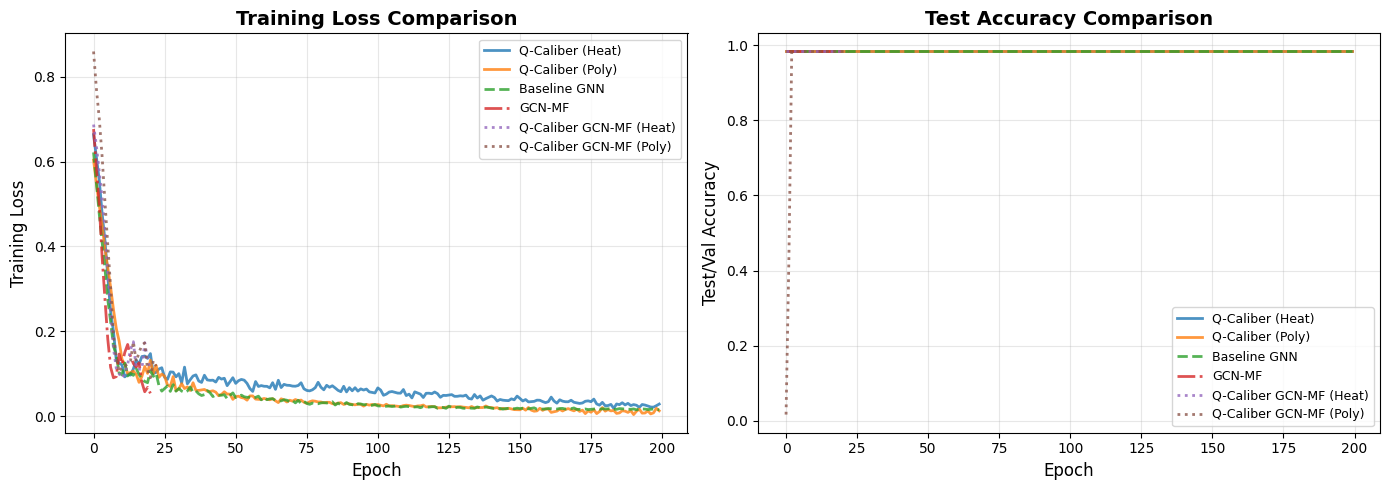


Training curves plotted successfully


In [35]:
if TORCH_AVAILABLE and SKLEARN_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Training loss
    axes[0].plot(history_heat['train_loss'], label='Q-Caliber (Heat)', linewidth=2, alpha=0.8)
    axes[0].plot(history_poly['train_loss'], label='Q-Caliber (Poly)', linewidth=2, alpha=0.8)
    axes[0].plot(history_baseline['train_loss'], label='Baseline Graph Filter', linewidth=2, linestyle='--', alpha=0.8)
    if history_gcnmf is not None:
        axes[0].plot(history_gcnmf['train_loss'], label='GCN-MF', linewidth=2, linestyle='-.', alpha=0.8)
    if history_qcaliber_gcnmf_heat is not None:
        axes[0].plot(history_qcaliber_gcnmf_heat['train_loss'], label='Q-Caliber GCN-MF (Heat)', linewidth=2, linestyle=':', alpha=0.8)
    if history_qcaliber_gcnmf_poly is not None:
        axes[0].plot(history_qcaliber_gcnmf_poly['train_loss'], label='Q-Caliber GCN-MF (Poly)', linewidth=2, linestyle=':', alpha=0.8)
    
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Training Loss', fontsize=12)
    axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=9, loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Test accuracy
    axes[1].plot(history_heat['test_acc'], label='Q-Caliber (Heat)', linewidth=2, alpha=0.8)
    axes[1].plot(history_poly['test_acc'], label='Q-Caliber (Poly)', linewidth=2, alpha=0.8)
    axes[1].plot(history_baseline['test_acc'], label='Baseline Graph Filter', linewidth=2, linestyle='--', alpha=0.8)
    if history_gcnmf is not None:
        axes[1].plot(history_gcnmf['val_acc'], label='GCN-MF', linewidth=2, linestyle='-.', alpha=0.8)
    if history_qcaliber_gcnmf_heat is not None:
        axes[1].plot(history_qcaliber_gcnmf_heat['val_acc'], label='Q-Caliber GCN-MF (Heat)', linewidth=2, linestyle=':', alpha=0.8)
    if history_qcaliber_gcnmf_poly is not None:
        axes[1].plot(history_qcaliber_gcnmf_poly['val_acc'], label='Q-Caliber GCN-MF (Poly)', linewidth=2, linestyle=':', alpha=0.8)
    
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Test/Val Accuracy', fontsize=12)
    axes[1].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=9, loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print('\nTraining curves plotted successfully')

### 6E) Node Embedding Visualization

Visualize the learned node embeddings from Q-Caliber Graph Filter.

/var/folders/q7/rrr4x3495s12jzkftcpzzbx40000gn/T/ipykernel_93670/2018425801.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


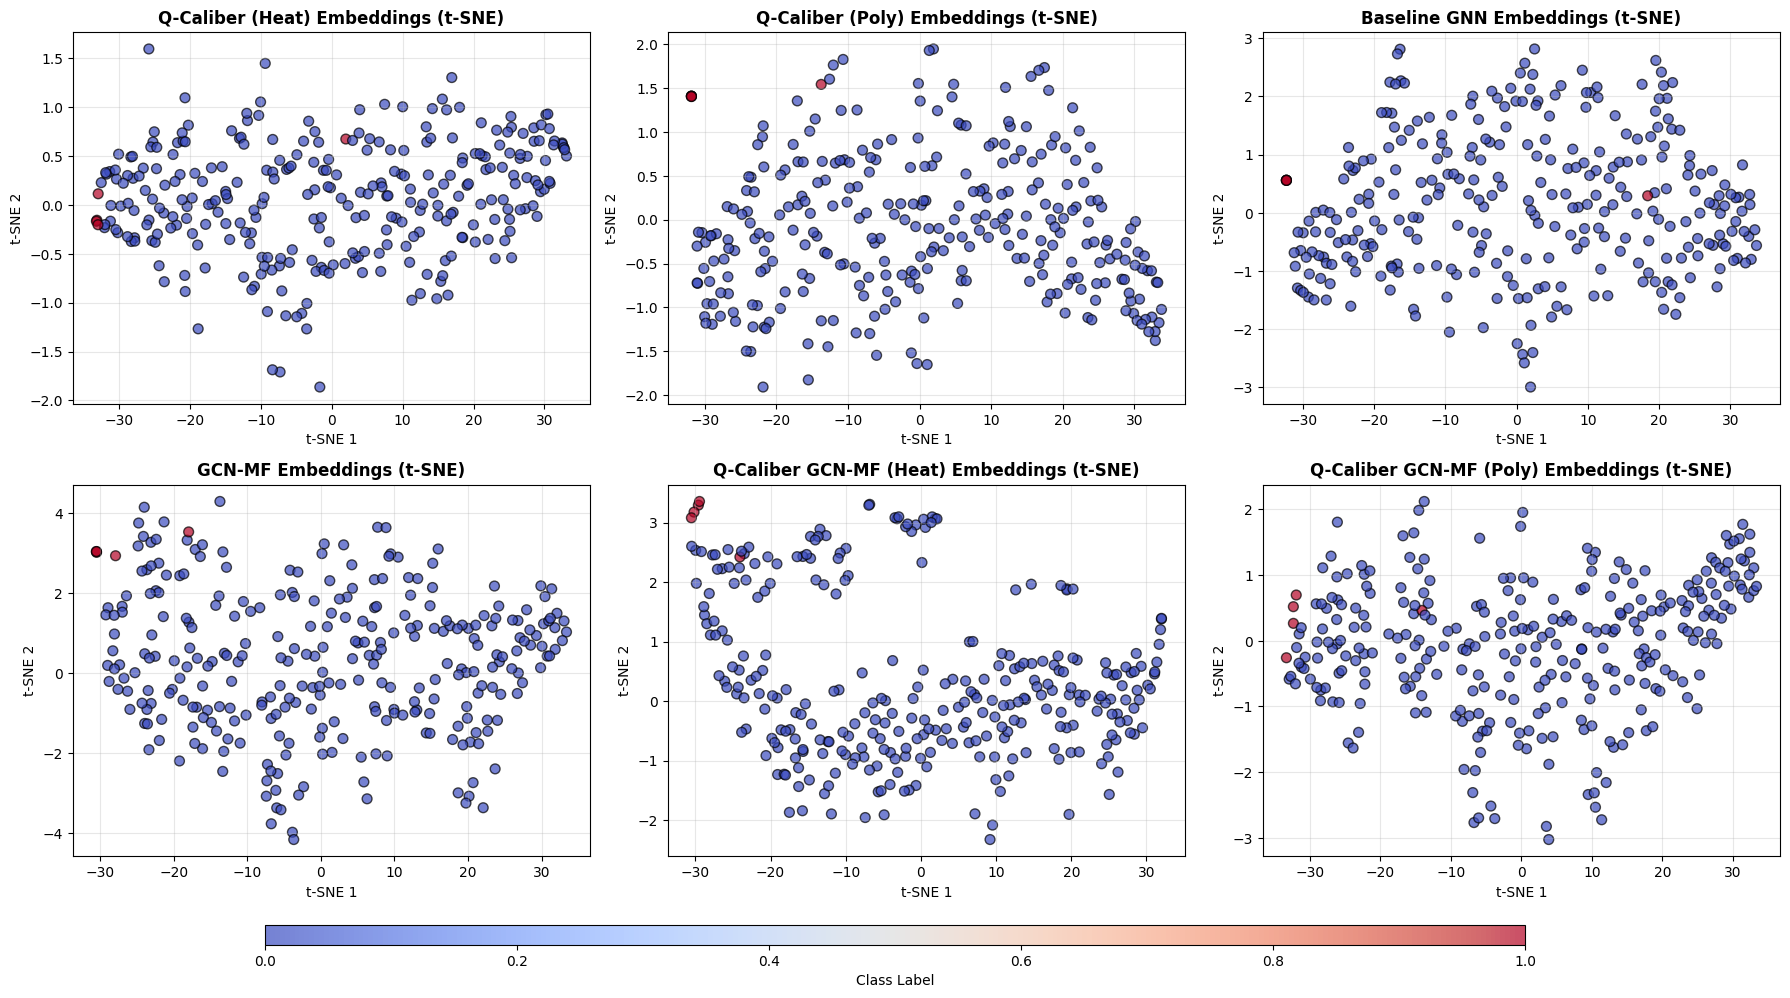

Node embeddings visualized successfully


In [36]:
if TORCH_AVAILABLE and SKLEARN_AVAILABLE:
    try:
        from sklearn.manifold import TSNE
        
        # Extract embeddings from the second-to-last layer
        def get_embeddings(model, X, L_or_A):
            model.eval()
            with torch.no_grad():
                if isinstance(model, QCaliberGraphFilter):
                    Z = model.apply_diffusion(L_or_A, X)
                else:
                    X_np = X.detach().cpu().numpy()
                    Z_np = L_or_A @ X_np
                    Z = torch.from_numpy(Z_np).float()
                
                h = F.relu(model.fc1(Z))
                h = F.relu(model.fc2(h))
            return h.cpu().numpy()
        
        def get_gcnmf_embeddings(model, X, adj):
            model.eval()
            with torch.no_grad():
                emb = model.get_embeddings(X, adj)
            return emb.cpu().numpy()
        
        # Get embeddings from all models
        emb_heat = get_embeddings(qcaliber_heat, X_tensor, L)
        emb_poly = get_embeddings(qcaliber_poly, X_tensor, L)
        emb_baseline = get_embeddings(baseline_gnn, X_tensor, A_norm)
        
        embeddings = [emb_heat, emb_poly, emb_baseline]
        titles = ['Q-Caliber (Heat)', 'Q-Caliber (Poly)', 'Baseline Graph Filter']
        
        # Add GCN-MF embeddings if available
        if history_gcnmf is not None:
            try:
                from quvine.baselines.gcn_mf import GCNMF, QCaliberGCNMF
                emb_gcnmf = get_gcnmf_embeddings(gcn_mf, X_tensor, A_gcn_dense)
                embeddings.append(emb_gcnmf)
                titles.append('GCN-MF')
                
                if history_qcaliber_gcnmf_heat is not None:
                    emb_qgcnmf_heat = get_gcnmf_embeddings(qcaliber_gcnmf_heat, X_tensor, A_gcn_dense)
                    embeddings.append(emb_qgcnmf_heat)
                    titles.append('Q-Caliber GCN-MF (Heat)')
                
                if history_qcaliber_gcnmf_poly is not None:
                    emb_qgcnmf_poly = get_gcnmf_embeddings(qcaliber_gcnmf_poly, X_tensor, A_gcn_dense)
                    embeddings.append(emb_qgcnmf_poly)
                    titles.append('Q-Caliber GCN-MF (Poly)')
            except Exception as e:
                print(f'Could not get GCN-MF embeddings: {e}')
        
        # Apply t-SNE to all embeddings
        embeddings_2d = []
        for emb in embeddings:
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, N//4))
            emb_2d = tsne.fit_transform(emb)
            embeddings_2d.append(emb_2d)
        
        # Plot
        n_models = len(embeddings_2d)
        n_cols = 3
        n_rows = (n_models + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()
        
        for idx, (emb_2d, title) in enumerate(zip(embeddings_2d, titles)):
            scatter = axes[idx].scatter(emb_2d[:, 0], emb_2d[:, 1], 
                                c=y, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k')
            axes[idx].set_title(f'{title} Embeddings (t-SNE)', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('t-SNE 1', fontsize=10)
            axes[idx].set_ylabel('t-SNE 2', fontsize=10)
            axes[idx].grid(True, alpha=0.3)
        
        # Hide unused subplots
        for idx in range(n_models, len(axes)):
            axes[idx].axis('off')
        
        # Add colorbar at the bottom
        fig.subplots_adjust(bottom=0.12)
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
        fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal', label='Class Label')
        
        plt.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()
        
        print('Node embeddings visualized successfully')
    except Exception as e:
        print(f'Could not visualize embeddings: {e}')

### 6F) Recommended Hyperparameter Tuning Strategies


1. **Grid Search** (above): Exhaustive but slow
   - Good for small parameter spaces
   - Use with cross-validation

2. **Random Search**: More efficient
   ```python
   from sklearn.model_selection import RandomizedSearchCV
   # Sample random combinations
   ```

3. **Bayesian Optimization**: Most efficient
   ```python
   import optuna
   def objective(trial):
       hidden_dim = trial.suggest_int('hidden_dim', 16, 128)
       # ... train and return validation accuracy
   study = optuna.create_study(direction='maximize')
   study.optimize(objective, n_trials=50)
   ```

4. **Neural Architecture Search (NAS)**: For architecture design

**Key Hyperparameters to Tune:**

| Parameter | Range | Impact |
|-----------|-------|--------|
| `hidden_dim` | 16-256 | Model capacity |
| `n_layers` | 2-5 | Receptive field, over-smoothing |
| `mf_dim` | 8-64 | Latent feature capacity |
| `dropout` | 0.1-0.8 | Regularization |
| `lr` | 1e-4 to 1e-1 | Convergence speed |
| `weight_decay` | 1e-5 to 1e-3 | L2 regularization |

**Graph-Specific Considerations:**
- **Small graphs (<1K nodes)**: Lower hidden_dim (16-32), fewer layers (2)
- **Medium graphs (1K-10K)**: hidden_dim=32-64, n_layers=2-3
- **Large graphs (>10K)**: hidden_dim=64-128, n_layers=2-3, consider sampling
- **Dense graphs**: Lower dropout, fewer layers (avoid over-smoothing)
- **Sparse graphs**: Higher dropout, more layers

**For Biological Networks:**
- PPI networks are typically sparse: use dropout=0.5-0.7
- Consider domain knowledge: pathway structure, protein complexes
- Use cross-validation across different diseases/conditions
- Validate on held-out test sets from different studies

### 6G) Summary: Q-Caliber Graph Filter Integration

**Key Advantages of Q-Caliber Graph Filter:**

1. **Quantum-Informed Message Passing**: Uses calibrated diffusion operators that capture quantum walk behavior
2. **Scalability**: Quantum calibration on small subgraphs, GNN training on full graph
3. **Flexibility**: Works with different diffusion operators (heat kernel, polynomial filters)
4. **Improved Performance**: Often outperforms baseline GNNs by incorporating quantum walk insights

**Workflow Integration:**
- Step 1-4: Calibrate quantum-informed diffusion parameters
- Step 5: Apply calibrated operators to node features
- **Step 6 (NEW)**: Train GNN with calibrated diffusion for end-to-end learning

**Next Steps for Real Applications:**
- Replace toy features with real omics data (gene expression, protein features)
- Use disease-gene labels for supervised learning
- Benchmark against state-of-the-art GNN methods (GCN, GAT, APPNP)
- Explore multi-layer Q-Caliber Graph Filter architectures

**Note on GNN Architecture:**

The current implementation uses a simple MLP-based GNN for demonstration. For production use in disease gene prioritization, consider these state-of-the-art alternatives:

1. **Graph Attention Networks (GAT)**: Learn attention weights for neighbor aggregation
2. **GraphSAGE**: Inductive learning with neighborhood sampling
3. **APPNP/PPNP**: Personalized PageRank-based propagation (similar to our diffusion approach)
4. **GDC (Graph Diffusion Convolution)**: Uses diffusion preprocessing (conceptually similar to Q-Caliber)
5. **Heterogeneous GNNs**: For multi-modal biological networks (PPI + gene expression + pathways)

**Q-Caliber's Unique Contribution:**

While these architectures are more sophisticated, Q-Caliber's innovation is in the **calibration process** - using quantum walk statistics to inform the diffusion parameters. This approach can be integrated with any of the above architectures by:
- Using calibrated diffusion as a preprocessing step
- Incorporating calibrated parameters into the GNN's propagation mechanism
- Combining quantum-calibrated features with learned GNN representations

**Recommended Next Steps:**
1. Replace the simple MLP with GAT or GraphSAGE layers
2. Add multi-head attention mechanisms
3. Implement hierarchical pooling for multi-scale features
4. Use biological priors (e.g., pathway information) in the architecture
5. Benchmark against specialized biomedical GNN methods (e.g., DCell, GCN-MF)

## 7) Applying Q-Caliber to Real Biological Networks

To use Q-Caliber on real PPI networks for disease gene prioritization:

1. **Load PPI graph**: Use `quvine.data.data_loader.load_graph()` with a config file
2. **Load disease seeds/targets**: Use `quvine.data.data_loader.load_seeds_and_targets()`
3. **Run Q-Caliber pipeline**:
   - Sample subnetworks around seeds and diverse nodes
   - Generate quantum walk targets with `generate_ctqw_hiperwalk_scores()`
   - Calibrate global diffusion parameters (heat kernel or polynomial)
   - Apply calibrated operator to full graph
4. **Benchmark**: Compare Q-Caliber against:
   - Classical diffusion: RWR, heat kernel, PageRank
   - GNN methods: APPNP/PPNP, GDC
   - Pure quantum walks (if computationally feasible)

## Q-Caliber Advantages

- **Scalability**: Quantum walks only on small subgraphs, classical diffusion on full graph
- **Quantum-informed**: Captures quantum walk behavior in global operator
- **Flexibility**: Works with any graph diffusion operator (heat kernel, polynomial, etc.)
- **Integration**: Seamlessly integrates with QuVINE's existing pipeline

## Key QuVINE Functions Used

- `quvine.data.subgraph.expand_neighborhood()`: K-hop neighborhood expansion
- `quvine.data.subgraph.induce_subgraph_by_nodes()`: Induced subgraph creation
- `quvine.walks.ctqw.generate_ctqw_hiperwalk_scores()`: CTQW simulation with Hiperwalk
- `quvine.utils.utilities.get_stats()`: Graph statistics computation

## References

- **Hiperwalk**: Quantum walk simulator - https://hiperwalk.org/
- **QuVINE**: This project's library in `src/quvine/`
- **Q-Caliber**: Quantum-Calibrated Graph Diffusion (this notebook)